In [9]:
import pandas as pd
import numpy as np
from vendi_score import vendi
from sklearn.metrics.pairwise import rbf_kernel

Dataset Preparation

In [10]:
df_all = pd.read_parquet("../0_data/processed_data/data_with_all_features_scaled.parquet")
df_low = df_all[df_all['MP_label'] == 'L'].reset_index(drop=True)
df_high = df_all[df_all['MP_label'] == 'H'].reset_index(drop=True)

df_rfe_all = pd.read_parquet('../0_data/processed_data/data_with_selected_features_LGB_All_scaled.parquet')
df_rfe_low =  df_rfe_all[df_rfe_all['MP_label'] == 'L'].reset_index(drop=True)
df_rfe_high = df_rfe_all[df_rfe_all['MP_label'] == 'H'].reset_index(drop=True)

Selecting the appropriate Gamma

In [ ]:
# Checking whether default Gamma can be used
X = df_all.drop(columns=['MP', 'SMILES', 'Type', 'MP_label'], errors='ignore').values

features = df_all.drop(columns=['MP', 'SMILES', 'Type', 'MP_label'], errors='ignore')
n_features = features.shape[1]
print(f"Number of feature columns: {n_features}")

# Set it to fixed gamma (across all datasets):
fixed_gamma = 1 / n_features
print(f"Your fixed gamma is: {fixed_gamma:.6f}")

# Calculate K with the current gamma, RBF kernel selected (____________________)
K = rbf_kernel(X, gamma=fixed_gamma)

# Average similarity off the diagonal
off_diag = K[~np.eye(K.shape[0], dtype=bool)]
print(f"Average off-diagonal similarity: {np.mean(off_diag):.4f}")

Number of feature columns: 384
Your fixed gamma is: 0.002604
Average off-diagonal similarity: 0.2216


In [12]:
# Make the Vendi score calculation into a for loop

# 1. Define your fixed gamma once based on the INITIAL full feature set: ensures every comparison uses the same 'magnification'
n_features_initial = df_all.drop(columns=['MP', 'SMILES', 'Type', 'MP_label'], errors='ignore').shape[1]
fixed_gamma = 1 / n_features_initial

def calculate_vendi_metrics(df, name, gamma):
    """
    Calculates Vendi Score and Vendi Density for a given dataframe.
    """
    # Isolate features (numeric only)
    X = df.drop(columns=['MP', 'SMILES', 'Type', 'MP_label'], errors='ignore').values
    
    # Calculate Similarity Matrix K
    K = rbf_kernel(X, gamma=gamma)
    
    # Calculate Vendi Score
    vs_score = vendi.score_K(K)
    
    # Calculate Vendi Density (Score normalized by sample size)
    density = vs_score / len(df)
    
    print(f"--- {name} ---")
    print(f"Sample Count: {len(df)}")
    print(f"Vendi Score:  {vs_score:.4f}")
    print(f"Vendi Density: {density:.4f}\n")
    
    return {"name": name, "score": vs_score, "density": density}

In [13]:
# 2. Create a dictionary of the datasets

datasets = {
    "All Data": df_all,
    "Low MP": df_low,
    "High MP": df_high,
    "All Data (RFE)": df_rfe_all,
    "Low MP (RFE)": df_rfe_low,
    "High MP (RFE)": df_rfe_high
}

# 3. Run the loop
results = []
for label, data in datasets.items():
    res = calculate_vendi_metrics(data, label, fixed_gamma)
    results.append(res)

--- All Data ---
Sample Count: 17220
Vendi Score:  272.5191
Vendi Density: 0.0158

--- Low MP ---
Sample Count: 16342
Vendi Score:  253.6129
Vendi Density: 0.0155

--- High MP ---
Sample Count: 878
Vendi Score:  176.5345
Vendi Density: 0.2011

--- All Data (RFE) ---
Sample Count: 17220
Vendi Score:  6.4940
Vendi Density: 0.0004

--- Low MP (RFE) ---
Sample Count: 16342
Vendi Score:  6.2384
Vendi Density: 0.0004

--- High MP (RFE) ---
Sample Count: 878
Vendi Score:  8.8148
Vendi Density: 0.0100



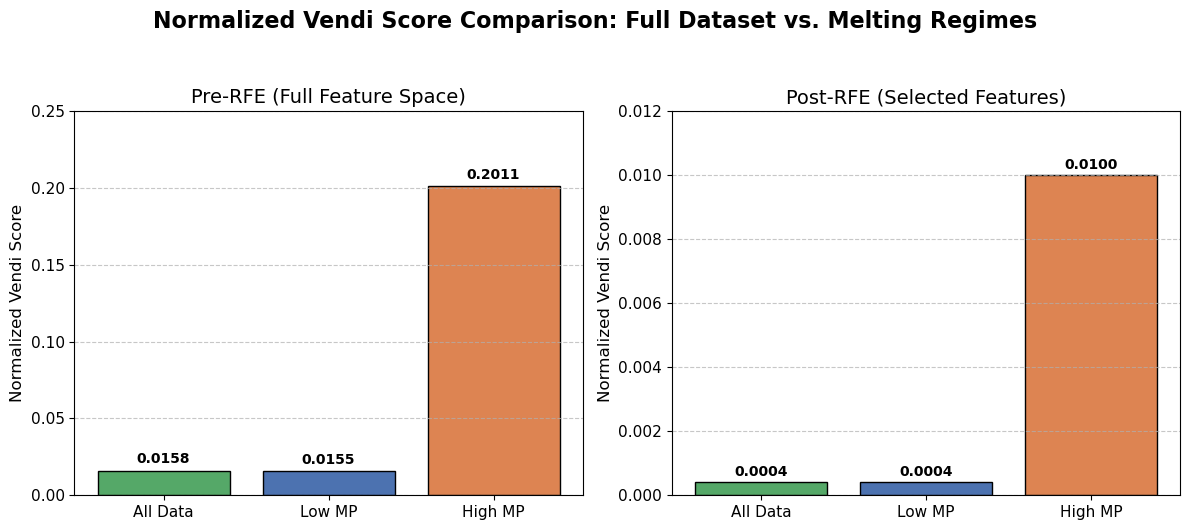

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your screenshot including 'All Data'
categories = ['All Data', 'Low MP', 'High MP']
density_pre = [0.0158, 0.0155, 0.2011]
density_post = [0.0004, 0.0004, 0.0100]

# Set up the figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
fig.suptitle('Normalized Vendi Score Comparison: Full Dataset vs. Melting Regimes', fontsize=16, fontweight='bold', y=1.05)

# Color palette: Green for All Data, Blue for Low, Orange for High
colors = ['#55A868', '#4C72B0', '#DD8452'] 

# Subplot 1: Pre-RFE
axes[0].bar(categories, density_pre, color=colors, edgecolor='black')
axes[0].set_title('Pre-RFE (Full Feature Space)', fontsize=14)
axes[0].set_ylabel('Normalized Vendi Score', fontsize=12)
axes[0].set_ylim(0, 0.25) # Give headroom for the text

# Add text labels on top of bars
for i, v in enumerate(density_pre):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

# Subplot 2: Post-RFE
axes[1].bar(categories, density_post, color=colors, edgecolor='black')
axes[1].set_title('Post-RFE (Selected Features)', fontsize=14)
axes[1].set_ylabel('Normalized Vendi Score', fontsize=12)
axes[1].set_ylim(0, 0.012) # Different scale for the selected features

# Add text labels on top of bars
for i, v in enumerate(density_post):
    axes[1].text(i, v + 0.0002, f"{v:.4f}", ha='center', fontweight='bold')

# Formatting
for ax in axes:
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
#plt.savefig('vendi_density_comparison_with_all.png', dpi=300, bbox_inches='tight')
plt.show()

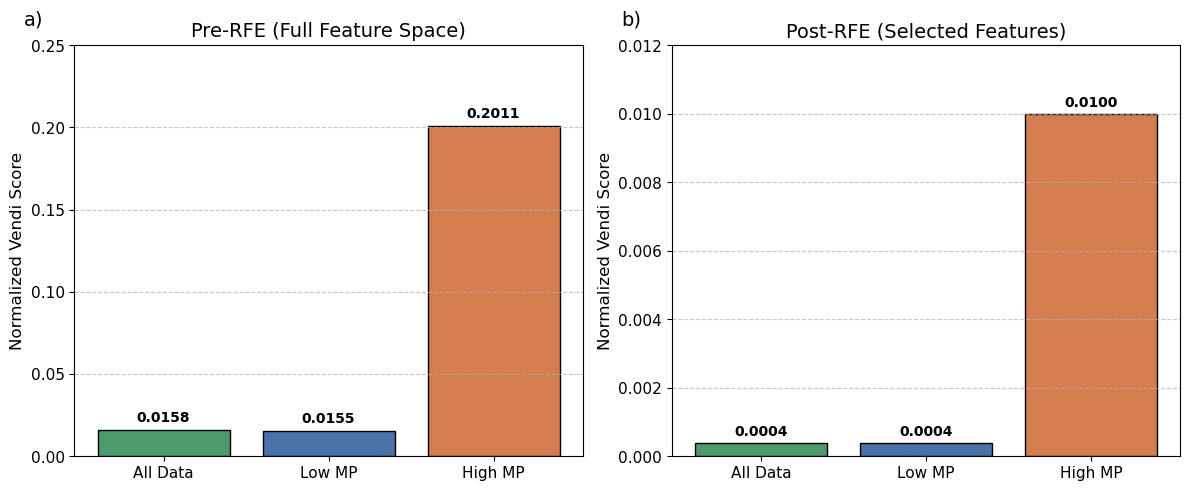

In [9]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['All Data', 'Low MP', 'High MP']
density_pre = [0.0158, 0.0155, 0.2011]
density_post = [0.0004, 0.0004, 0.0100]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

#colors = ['#55a868', '#4c72b0', '#dd8452']

colors = ['#4E9A6E', '#4A72A8', '#D47E50']

# Subplot a: Pre-RFE
axes[0].bar(categories, density_pre, color=colors, edgecolor='black')
axes[0].set_title('Pre-RFE (Full Feature Space)', fontsize=14)
axes[0].set_ylabel('Normalized Vendi Score', fontsize=12)
axes[0].set_ylim(0, 0.25)
axes[0].text(-0.1, 1.05, 'a)', transform=axes[0].transAxes, fontsize=14)

for i, v in enumerate(density_pre):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

# Subplot b: Post-RFE
axes[1].bar(categories, density_post, color=colors, edgecolor='black')
axes[1].set_title('Post-RFE (Selected Features)', fontsize=14)
axes[1].set_ylabel('Normalized Vendi Score', fontsize=12)
axes[1].set_ylim(0, 0.012)
axes[1].text(-0.1, 1.05, 'b)', transform=axes[1].transAxes, fontsize=14)

for i, v in enumerate(density_post):
    axes[1].text(i, v + 0.0002, f"{v:.4f}", ha='center', fontweight='bold')

for ax in axes:
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()